# CompEcon vs hetmacro — Visual Comparison

This notebook provides visual comparisons between CompEcon and hetmacro for key foundational tools. It focuses on:

- Quadrature accuracy and node/weight behavior
- Chebyshev approximation quality
- Grid orientation differences

The goal is to make differences and compatibility clear at a glance.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure repo root is on sys.path so `import hetmacro` works
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from compecon import quad as cquad
from compecon import basisChebyshev
from compecon import tools as ctools

from hetmacro import quadrature as hquad
from hetmacro import interpolation as hinterp
from hetmacro import grids as hgrids

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True})

print("Imports loaded.")

Imports loaded.


## 1) Quadrature comparison (Legendre and Chebyshev)

We compare:
- **Gauss‑Legendre** accuracy for integrating a smooth function on a bounded interval.
- **Chebyshev rules**: hetmacro Gauss‑Chebyshev vs CompEcon Clenshaw‑Curtis.

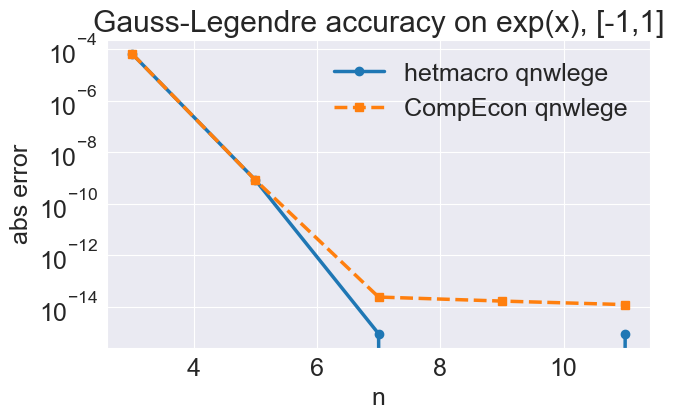

In [2]:
def quad_expectation(nodes, weights, f):
    return np.sum(weights * f(nodes))

# Test function and exact integral on [-1,1]
# f(x) = exp(x), integral = e - 1/e
f = np.exp
exact = np.e - 1 / np.e

ns = [3, 5, 7, 9, 11]
err_h = []
err_c = []

for n in ns:
    xh, wh = hquad.qnwlege(n, -1, 1)
    xc, wc = cquad.qnwlege(n, -1, 1)
    err_h.append(abs(quad_expectation(xh, wh, f) - exact))
    err_c.append(abs(quad_expectation(xc, wc, f) - exact))

plt.figure(figsize=(7, 4))
plt.semilogy(ns, err_h, "o-", label="hetmacro qnwlege")
plt.semilogy(ns, err_c, "s--", label="CompEcon qnwlege")
plt.xlabel("n")
plt.ylabel("abs error")
plt.title("Gauss-Legendre accuracy on exp(x), [-1,1]")
plt.legend()
plt.show()

In [3]:
err_h

[6.54586075912178e-05,
 8.247771354774613e-10,
 8.881784197001252e-16,
 0.0,
 8.881784197001252e-16]

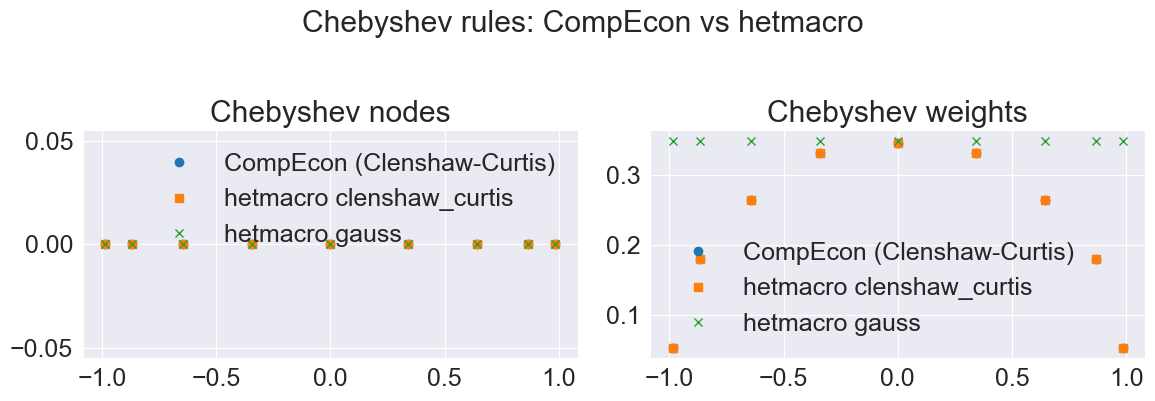

Sum of weights:
CompEcon (clenshaw): 2.0
hetmacro clenshaw:    2.0
hetmacro gauss:       3.141592653589793


In [4]:
n = 9

# CompEcon Chebyshev = Clenshaw-Curtis weights on Chebyshev nodes
xc, wc = cquad.qnwcheb(n, -1, 1)

# hetmacro: Gauss-Chebyshev (weighted) vs Clenshaw-Curtis (CompEcon-compatible)
xg, wg = hquad.qnwcheb(n, -1, 1, kind="gauss")
xl, wl = hquad.qnwcheb(n, -1, 1, kind="clenshaw_curtis")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nodes comparison
axes[0].plot(xc, np.zeros_like(xc), "o", label="CompEcon (Clenshaw-Curtis)")
axes[0].plot(xl, np.zeros_like(xl), "s", label="hetmacro clenshaw_curtis")
axes[0].plot(xg, np.zeros_like(xg), "x", label="hetmacro gauss")
axes[0].set_title("Chebyshev nodes")
axes[0].legend()

# Weights comparison
axes[1].plot(xc, wc, "o", label="CompEcon (Clenshaw-Curtis)")
axes[1].plot(xl, wl, "s", label="hetmacro clenshaw_curtis")
axes[1].plot(xg, wg, "x", label="hetmacro gauss")
axes[1].set_title("Chebyshev weights")
axes[1].legend()

plt.suptitle("Chebyshev rules: CompEcon vs hetmacro", y=1.02)
plt.tight_layout()
plt.show()

print("Sum of weights:")
print("CompEcon (clenshaw):", wc.sum())
print("hetmacro clenshaw:   ", wl.sum())
print("hetmacro gauss:      ", wg.sum())

## 2) Chebyshev approximation (function interpolation)

We approximate the same function with Chebyshev bases in both libraries and compare the fit.

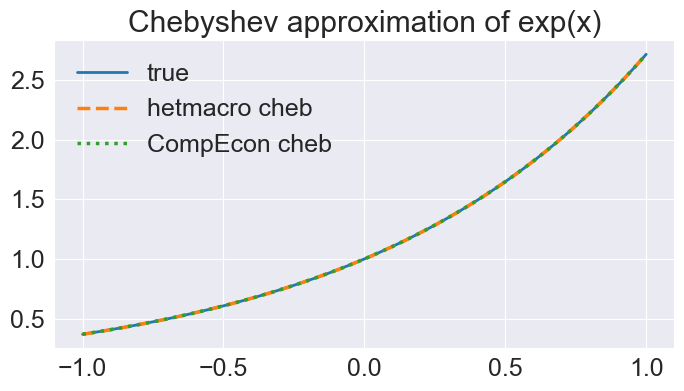

Max error hetmacro: 1.2190072062878698e-08
Max error CompEcon: 1.2190071174700279e-08


In [5]:
a, b = -1.0, 1.0
n = 9
x_plot = np.linspace(a, b, 400)

# hetmacro Chebyshev approximation
coef = hinterp.cheb_coef(np.exp, n=n, a=a, b=b)
fh = hinterp.cheb_eval(coef, x_plot, a=a, b=b)

# CompEcon Chebyshev approximation (BasisChebyshev)
cb = basisChebyshev.BasisChebyshev(n, a, b)
cb.y = np.exp(cb.x)
cb.update_c()
Phi = cb.Phi(x_plot)
fc = (cb.c @ Phi.T).ravel()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x_plot, np.exp(x_plot), label="true", linewidth=2)
plt.plot(x_plot, fh, "--", label="hetmacro cheb")
plt.plot(x_plot, fc, ":", label="CompEcon cheb")
plt.title("Chebyshev approximation of exp(x)")
plt.legend()
plt.show()

# Error comparison
err_h = np.max(np.abs(fh - np.exp(x_plot)))
err_c = np.max(np.abs(fc - np.exp(x_plot)))
print("Max error hetmacro:", err_h)
print("Max error CompEcon:", err_c)

## 3) Grid orientation difference

Both libraries generate the same Cartesian product points, but the output layout differs:
- **CompEcon**: shape `(d, N)`
- **hetmacro**: shape `(N, d)`

In [6]:
x1 = np.array([1, 2, 3])
x2 = np.array([4, 5])

cg = ctools.gridmake(x1, x2)
hg = hgrids.gridmake(x1, x2)

print("CompEcon gridmake shape:", cg.shape)
print("hetmacro gridmake shape:", hg.shape)

print("CompEcon (d,N)\n", cg)
print("hetmacro (N,d)\n", hg)

# They contain the same points, just transposed
print("Points equal after transpose:", np.allclose(cg.T, hg))

CompEcon gridmake shape: (2, 6)
hetmacro gridmake shape: (6, 2)
CompEcon (d,N)
 [[1 1 2 2 3 3]
 [4 5 4 5 4 5]]
hetmacro (N,d)
 [[1 4]
 [1 5]
 [2 4]
 [2 5]
 [3 4]
 [3 5]]
Points equal after transpose: True


## 4) Interpolation comparison (Linear basis)

We compare linear interpolation using:
- **hetmacro** `interp_linear`
- **CompEcon** `BasisLinear`

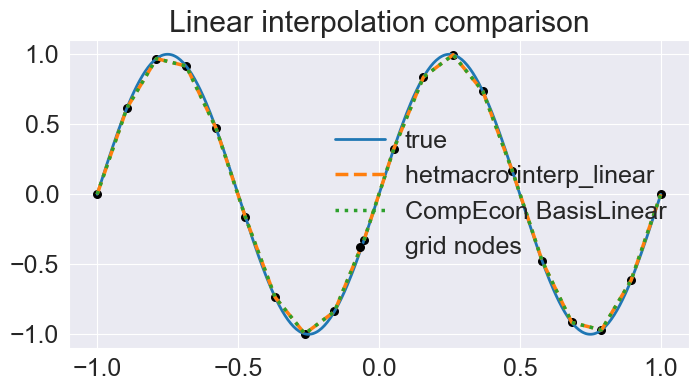

Max |diff| between methods: 1.1102230246251565e-15


In [7]:
from compecon import basisLinear

n = 20


# Data on a coarse grid
x_grid = np.linspace(-1, 1, n)
y_grid = np.sin(2 * np.pi * x_grid)

# Fine grid for evaluation
x_eval = np.linspace(-1, 1, 400)

# hetmacro linear interpolation
fh = hinterp.interp_linear(x_grid, y_grid, x_eval)

# CompEcon linear basis
cb = basisLinear.BasisLinear(len(x_grid), -1, 1)
cb.y = y_grid
cb.update_c()
Phi = cb.Phi(x_eval)
fc = (cb.c @ Phi.T).ravel()

plt.figure(figsize=(8, 4))
plt.plot(x_eval, np.sin(2 * np.pi * x_eval), label="true", linewidth=2)
plt.plot(x_eval, fh, "--", label="hetmacro interp_linear")
plt.plot(x_eval, fc, ":", label="CompEcon BasisLinear")
plt.scatter(x_grid, y_grid, s=30, color="black", label="grid nodes")
plt.title("Linear interpolation comparison")
plt.legend()
plt.show()

print("Max |diff| between methods:", np.max(np.abs(fh - fc)))

## 4.5) Interpolation comparison (Spline)

We compare cubic spline interpolation using:
- **hetmacro** `spline_coef` / `spline_eval`
- **CompEcon** `BasisSpline`

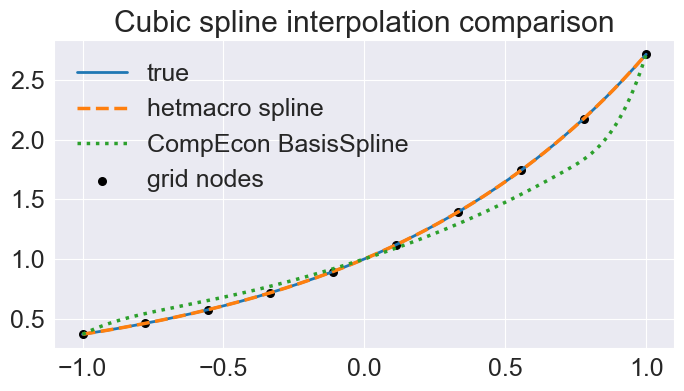

Max |diff| between methods: 0.35475409394778024


In [8]:
from compecon import basisSpline

# Data on a coarse grid
x_grid = np.linspace(-1, 1, 10)
y_grid = np.exp(x_grid)

# Fine grid for evaluation
x_eval = np.linspace(-1, 1, 400)

# hetmacro spline interpolation
coef = hinterp.spline_coef(x_grid, y_grid, kind="cubic")
fh = hinterp.spline_eval(coef, x_eval)

# CompEcon spline basis
cs = basisSpline.BasisSpline(len(x_grid), -1, 1, k=3)
cs.y = y_grid
cs.update_c()
Phi = cs.Phi(x_eval)
fc = (cs.c @ Phi.T).ravel()

plt.figure(figsize=(8, 4))
plt.plot(x_eval, np.exp(x_eval), label="true", linewidth=2)
plt.plot(x_eval, fh, "--", label="hetmacro spline")
plt.plot(x_eval, fc, ":", label="CompEcon BasisSpline")
plt.scatter(x_grid, y_grid, s=30, color="black", label="grid nodes")
plt.title("Cubic spline interpolation comparison")
plt.legend()
plt.show()

print("Max |diff| between methods:", np.max(np.abs(fh - fc)))

## 5) Optimization comparison (Golden section)

We compare a simple 1D minimization using:
- **hetmacro** `golden_search`
- **CompEcon** `OP(...).golden`

Objective: minimize a convex function with a known minimum.

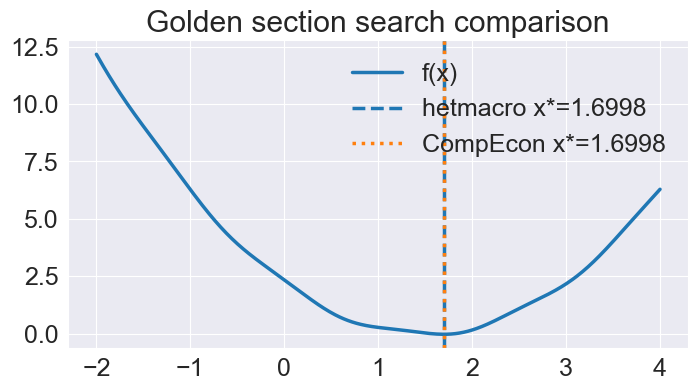

hetmacro x*: 1.6997841217553136
CompEcon x*: 1.6997841157869813
|diff|: 5.968332272843213e-09


In [9]:
from compecon import optimize as copt
from hetmacro import optimize as hopt

# Objective function with minimum at x=1.5
f = lambda x: (x - 1.5) ** 2 + 0.1 * np.cos(5 * x)

# hetmacro golden search
x_h = hopt.golden_search(f, a=-2.0, b=4.0, tol=1e-10)
# CompEcon OP golden search
op = copt.OP(lambda x: -f(x))   # maximize -f == minimize f
x_c = op.golden(-2.0, 4.0, tol=1e-10)

# Visual check
x_plot = np.linspace(-2, 4, 400)
plt.figure(figsize=(8, 4))
plt.plot(x_plot, f(x_plot), label="f(x)")
plt.axvline(x_h, color="tab:blue", linestyle="--", label=f"hetmacro x*={x_h:.4f}")
plt.axvline(x_c, color="tab:orange", linestyle=":", label=f"CompEcon x*={x_c:.4f}")
plt.title("Golden section search comparison")
plt.legend()
plt.show()

print("hetmacro x*:", x_h)
print("CompEcon x*:", x_c)
print("|diff|:", abs(x_h - x_c))

## 5.5) Optimization comparison (Quasi‑Newton / BFGS)

We compare:
- **SciPy BFGS** (as a quasi‑Newton baseline; this is what we would wrap in hetmacro if needed)
- **CompEcon** `OP(...).qnewton`

Note: CompEcon’s `OP.qnewton` maximizes the objective, so we pass `-f(x)` to minimize `f(x)`.

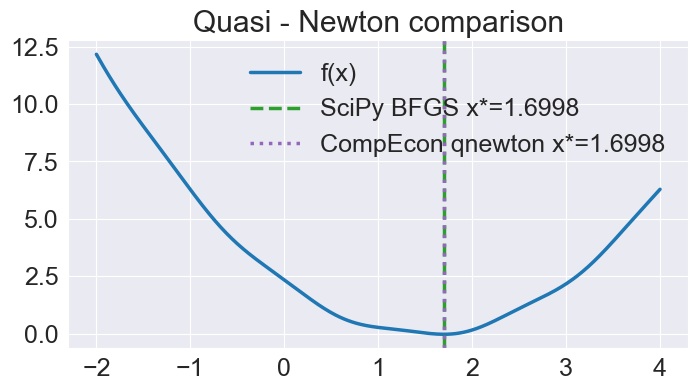

SciPy BFGS x*: 1.6997840977656697
CompEcon qnewton x*: 1.6997841172625046
|diff|: 1.9496834813281794e-08


In [10]:
from scipy import optimize as spopt

# Same objective as above
f = lambda x: (x - 1.5) ** 2 + 0.1 * np.cos(5 * x)

# CompEcon qnewton (maximize -f to minimize f)
def qn_obj(x):
    x_scalar = float(np.array(x).ravel()[0])
    return -f(x_scalar)


# SciPy BFGS (minimize f)
res = spopt.minimize(lambda x: f(x[0]), x0=np.array([0.0]), method="BFGS")
x_bfgs = res.x[0]

# CompEcon qnewton (maximize -f to minimize f)
op = copt.OP(qn_obj)
x_qn = op.qnewton(x0=np.array([0.0]))

if isinstance(x_qn, (list, tuple, np.ndarray)):
    x_qn = float(np.array(x_qn).ravel()[0])

# Visual check
x_plot = np.linspace(-2, 4, 400)
plt.figure(figsize=(8, 4))
plt.plot(x_plot, f(x_plot), label="f(x)")
plt.axvline(x_bfgs, color="tab:green", linestyle="--", label=f"SciPy BFGS x*={x_bfgs:.4f}")
plt.axvline(x_qn, color="tab:purple", linestyle=":", label=f"CompEcon qnewton x*={x_qn:.4f}")
plt.title("Quasi - Newton comparison")
plt.legend()
plt.show()

print("SciPy BFGS x*:", x_bfgs)
print("CompEcon qnewton x*:", x_qn)
print("|diff|:", abs(x_bfgs - x_qn))

## 6) Two‑dimensional interpolation (Bilinear)

We test 2D interpolation using **hetmacro** `interp_bilinear`, comparing the interpolated surface against the known true function on a fine grid.

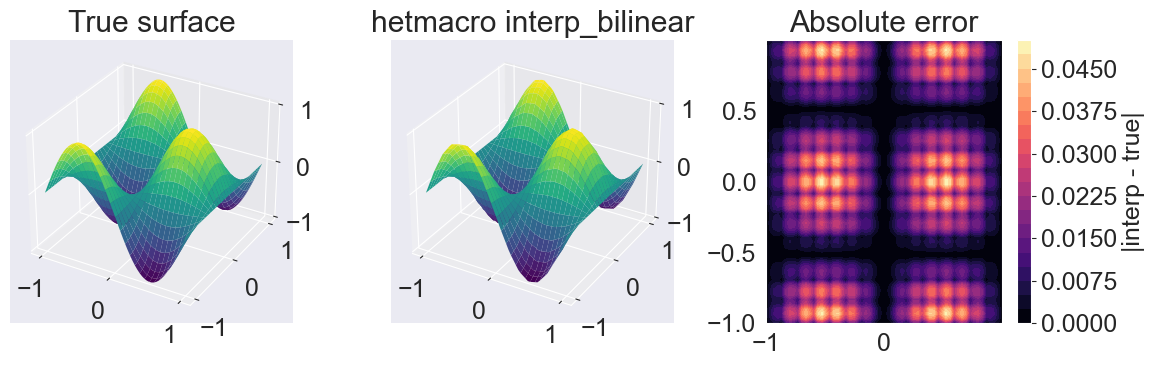

Max |error|: 0.04837397209742522


In [18]:
# Coarse 2D grid
n_x = 16
n_y = 14
x_grid = np.linspace(-1, 1, n_x)
y_grid = np.linspace(-1, 1, n_y)

# Values on the coarse grid
# With indexing="ij", Z has shape (len(x_grid), len(y_grid))
X, Y = np.meshgrid(x_grid, y_grid, indexing="ij")
Z = np.sin(np.pi * X) * np.cos(np.pi * Y)

# Evaluation grid (avoid exact endpoints to prevent edge indexing issues)
eps = 1e-6
xe = np.linspace(-1, 1, 60)
ye = np.linspace(-1, 1, 60)
Xe, Ye = np.meshgrid(xe, ye, indexing="ij")
Xe = np.clip(Xe, x_grid[0], x_grid[-1] - eps)
Ye = np.clip(Ye, y_grid[0], y_grid[-1] - eps)

# hetmacro bilinear interpolation
Zh = hinterp.interp_bilinear(x_grid, y_grid, Z, Xe, Ye)

# True surface on evaluation grid
Ztrue = np.sin(np.pi * Xe) * np.cos(np.pi * Ye)

# Visual check
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.plot_surface(Xe, Ye, Ztrue, cmap="viridis", linewidth=0)
ax1.set_title("True surface")

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(Xe, Ye, Zh, cmap="viridis", linewidth=0)
ax2.set_title("hetmacro interp_bilinear")

ax3 = fig.add_subplot(1, 3, 3)
diff = np.abs(Zh - Ztrue)
cf = ax3.contourf(Xe, Ye, diff, levels=20, cmap="magma")
fig.colorbar(cf, ax=ax3, label="|interp - true|")
ax3.set_title("Absolute error")

plt.tight_layout()
plt.show()

print("Max |error|:", float(np.max(diff)))

## Summary

- Quadrature: Legendre rules match closely; Chebyshev differs by default because CompEcon uses Clenshaw–Curtis weights. Use `qnwcheb(..., kind="clenshaw_curtis")` for CompEcon‑compatible results.
- Chebyshev approximation: both libraries produce similar fits for smooth functions.
- Gridmake: same points, different output orientation.